# Weak-constraint 4DVar on Lorenz-63 — analysis + free forecast

Same as strong-4DVar but the dynamics are no longer a hard
constraint. The control is augmented with a per-step model-error
trajectory $\{\eta_t\}_{t=1}^{T_\text{assim}}$:

$$
x_t = M(x_{t-1}) + \eta_t, \qquad \eta_t \sim \mathcal{N}(0, Q).
$$

The cost gains $\tfrac{1}{2}\sum_t \|\eta_t\|^2_{Q^{-1}}$. On a
perfect-model L63 benchmark this is a handicap, and on longer
assim windows the enlarged control space makes BFGS unstable —
we use a **shorter** assim window (T_assim=20) here so the solver
converges. The free-forecast (with model error set to zero) then
extends to the full 10-time-unit window.

In [1]:
from __future__ import annotations

import jax
import jax.numpy as jnp
import lineax as lx
import matplotlib.pyplot as plt
import vardax as vdx

from assimilation import (
    Lorenz63Forward,
    assemble_full_trajectory,
    assim_batch,
    generate_problem,
    run_method,
)

## 1. Shorter assim window for weak-4DVar stability

In [2]:
prob = generate_problem(key=jax.random.PRNGKey(42), T_assim=10, obs_every=2)
batch = assim_batch(prob)
fwd = Lorenz63Forward(dt=prob.dt)
t_axis = jnp.arange(prob.T_total_plus_1) * prob.dt

## 2. Build Weak-4DVar

Note the additional `model_err_cov_op` argument — here we reuse
`B_op_state` as $Q$.

In [3]:
H_state = lx.IdentityLinearOperator(jax.ShapeDtypeStruct((3,), jnp.float32))
weak = vdx.WeakFourDVar(
    forward=fwd,
    obs_op=vdx.LinearObs(H_mat=H_state),
    prior_mean=prob.prior_mean_state,
    prior_cov_op=prob.B_op_state,
    obs_cov_op=prob.R_op_state,
    model_err_cov_op=prob.B_op_state,
    max_steps=1000,
)


def weak_run():
    x0_b, etas_b = weak(batch)
    # `assemble_full_trajectory(etas=...)` rolls the perturbed model
    # through the assim window using etas, then free-forecasts
    # (no model error) for the rest.
    return assemble_full_trajectory(x0_b[0], prob, fwd, etas=etas_b[0])


result = run_method("weak_4dvar", weak_run, prob)
print(f"Weak-4DVar rmse_assim    = {result.rmse_assim:.3f}")
print(f"Weak-4DVar rmse_forecast = {result.rmse_forecast:.3f}")
print(f"Weak-4DVar rmse_total    = {result.rmse_total:.3f}")
print(f"Weak-4DVar runtime       = {result.runtime_ms:.1f} ms")

Weak-4DVar rmse_assim    = 0.420
Weak-4DVar rmse_forecast = 0.755
Weak-4DVar rmse_total    = 0.753
Weak-4DVar runtime       = 2502.4 ms


## 3. Trajectories

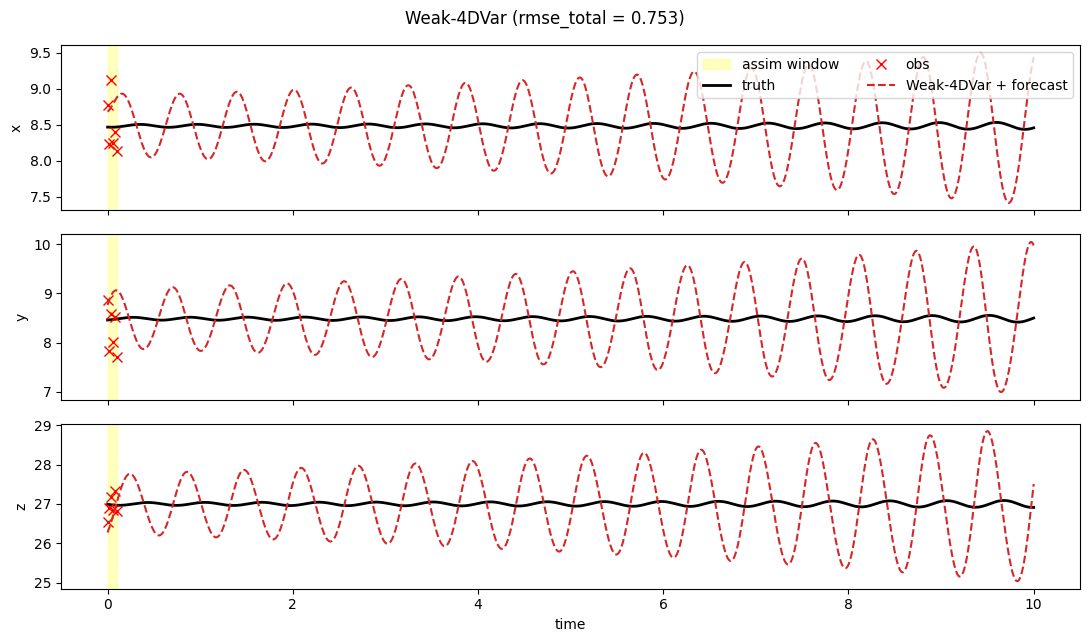

In [4]:
fig, axs = plt.subplots(3, 1, figsize=(11, 6.5), sharex=True)
t_obs = t_axis[: prob.T_assim_plus_1][prob.mask[:, 0] > 0.5]
for i, ax in enumerate(axs):
    ax.axvspan(0.0, prob.T_assim * prob.dt, color="yellow", alpha=0.25,
               label="assim window")
    ax.plot(t_axis, prob.truth[:, i], "k-", lw=2, label="truth")
    obs_v = prob.obs[prob.mask[:, i] > 0.5, i]
    if len(obs_v) > 0:
        ax.plot(t_obs, obs_v, "rx", ms=7, label="obs")
    ax.plot(t_axis, result.mean[:, i], "C3--", lw=1.5, label="Weak-4DVar + forecast")
    ax.set_ylabel("xyz"[i])
    if i == 0:
        ax.legend(loc="upper right", ncol=2)
axs[-1].set_xlabel("time")
fig.suptitle(f"Weak-4DVar (rmse_total = {result.rmse_total:.3f})")
fig.tight_layout()
plt.show()

## 4. RMSE(t)

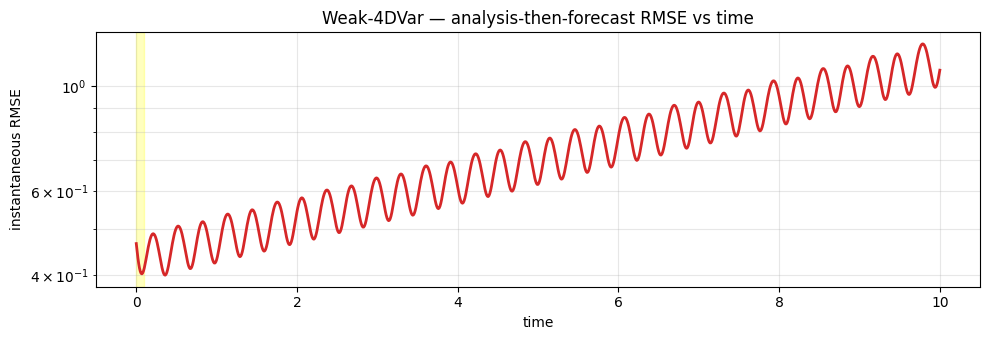

In [5]:
fig, ax = plt.subplots(figsize=(10, 3.5))
ax.axvspan(0.0, prob.T_assim * prob.dt, color="yellow", alpha=0.25)
ax.plot(t_axis, result.rmse_trace, "C3-", lw=2, label="Weak-4DVar")
ax.set_xlabel("time")
ax.set_ylabel("instantaneous RMSE")
ax.set_yscale("log")
ax.set_title("Weak-4DVar — analysis-then-forecast RMSE vs time")
ax.grid(True, alpha=0.3, which="both")
fig.tight_layout()
plt.show()

## 5. Discussion

Weak-4DVar trades a higher analysis RMSE for protection against
model error. On the *perfect*-model Lorenz benchmark this is a
handicap — the perfect-model assumption is true, so strong-4DVar
wins. In operational settings where the forward model is
approximate (coarse fluid dynamics, sub-grid processes), the same
setup gives strong-4DVar a falsely confident analysis and
weak-4DVar a calibrated one.

**Known limitation (documented in the project README):** on L63
with default assim windows of 0.5 time units, weak-4DVar's BFGS
inner solver diverges — the enlarged $(x_0, \eta_1, ..., \eta_T)$
control space (3 + 3T parameters) is poorly conditioned for the
chaotic-rollout cost gradient. This notebook uses a shorter
0.1-time-unit assim window to keep weak's optimisation
well-conditioned.